In [1]:
import os

import matplotlib.pyplot as plt
from sklearn.model_selection import RepeatedKFold

import torch
import tensorkrowch as tk

from utils import *

## Train LR model

In [2]:
cwd = os.path.join(os.getcwd(), '..')

model_name = 'lr'
n_classes = 2

featuresNA = ['TMB', 'Albumin', 'NLR', 'Age', 'Systemic_therapy_history',
              'CancerType1', 'CancerType2', 'CancerType3', 'CancerType4',
              'CancerType5', 'CancerType6', 'CancerType7', 'CancerType8',
              'CancerType9', 'CancerType10', 'CancerType11', 'CancerType12',
              'CancerType13', 'CancerType14', 'CancerType15', 'CancerType16']
phenoNA = 'Response'

numeric_featuresNA = ['TMB', 'Albumin', 'NLR', 'Age']

datasets = ['Chowell_train', 'Chowell_test', 'MSK1', 'MSK2', 'Shim_NSCLC',
            'Kato_panCancer', 'Vanguri_NSCLC', 'Ravi_NSCLC', 'Pradat_panCancer']

In [3]:
# Load data
# ---------
scaler_type = 'standard'

dataset = ['Chowell_train']
data_train, scalers_train = load_data(cwd,
                                      featuresNA,
                                      phenoNA,
                                      dataset,
                                      scaler_type)

dataset = ['Chowell_test']
data_test, scalers_test = load_data(cwd,
                                    featuresNA,
                                    phenoNA,
                                    dataset,
                                    scaler_type)

In [4]:
# Train vanilla model
# -------------------
x_train = data_train[featuresNA].values
y_train = data_train[phenoNA].values

x_test = data_test[featuresNA].values
y_test = data_test[phenoNA].values

loris_van = train_lr_model('vanilla', x_train, y_train, x_test, y_test)

*TRAINING MODEL*

Accuracy: Train: 0.69, Test: 0.72
Balanced accuracy: Train: 0.68, Test: 0.69

*Correct predicitons*
Train:
    Class 0: 486 / 682 (0.7126)
    Class 1: 182 / 282 (0.6454)
Test:
    Class 0: 288 / 388 (0.7423)
    Class 1: 82 / 127 (0.6457)



In [5]:
# Train average model
# -------------------
x_train = data_train[featuresNA].values
y_train = data_train[phenoNA].values

x_test = data_test[featuresNA].values
y_test = data_test[phenoNA].values

loris_avg = train_lr_model('average', x_train, y_train, x_test, y_test)

*TRAINING MODEL*

Accuracy: Train: 0.69, Test: 0.73
Balanced accuracy: Train: 0.68, Test: 0.69

*Correct predicitons*
Train:
    Class 0: 489 / 682 (0.7170)
    Class 1: 180 / 282 (0.6383)
Test:
    Class 0: 294 / 388 (0.7577)
    Class 1: 80 / 127 (0.6299)



## Tensorize

In [6]:
dataset = datasets
data_sketch, scalers_sketch = load_sketch_data(cwd,
                                               featuresNA,
                                               phenoNA,
                                               dataset,
                                               scaler_type,
                                               n_samples=10)

x_sketch = data_sketch[featuresNA].values
y_sketch = data_sketch[phenoNA].values

print(x_sketch.shape)

(297, 21)


In [7]:
xt_train = torch.from_numpy(x_train).float()
yt_train = torch.from_numpy(y_train)

xt_test = torch.from_numpy(x_test).float()
yt_test = torch.from_numpy(y_test)

xt_sketch = torch.from_numpy(x_sketch).float()
yt_sketch = torch.from_numpy(y_sketch)

In [8]:
# Tensorize model
# ---------------
sketch_size    = 100
phys_dim       = 2
domain         = None
bond_dim       = 2
cum_percentage = 1 - 1e-2
batch_size     = 1000
device         = torch.device('cpu')
dtype          = torch.float
verbose        = False


def fn_model(data, n_bins=6):
    # Get probabilities (numpy)
    y_proba = loris_van.predict_proba(data)
    y_proba = torch.from_numpy(y_proba).float()
    
    discr_out = discretize(vector=y_proba, n_bins=n_bins)
    return discr_out.sqrt()

def embedding(data):
    return tk.embeddings.poly(data, degree=phys_dim - 1).float()


mps = tensorize(fn_model=fn_model,
                embedding=embedding,
                x_train=xt_train,
                y_train=yt_train,
                x_test=xt_test,
                y_test=yt_test,
                x_sketch=xt_sketch,
                y_sketch=yt_sketch,
                sketch_size=sketch_size,
                phys_dim=phys_dim,
                domain=domain,
                bond_dim=bond_dim,
                cum_percentage=cum_percentage,
                batch_size=batch_size,
                device=device,
                dtype=dtype,
                verbose=verbose)

*TENSORIZING MODEL*

Info: {'total_time': 1.0209813117980957, 'val_eps': tensor(0.0770)}

MSE: Sketch: 8.00e-03, Train: 0.0078, Test: 8.08e-03
tensor([[0.8398, 0.5342],
        [0.0806, 1.0460],
        [0.7494, 0.6275],
        [0.7228, 0.6695],
        [0.8255, 0.5486],
        [0.6609, 0.6984],
        [0.8461, 0.5205],
        [0.4096, 0.8891],
        [0.0212, 1.0141],
        [0.8595, 0.5171]])
tensor([[0.8165, 0.5774],
        [0.0000, 1.0000],
        [0.8165, 0.5774],
        [0.8165, 0.5774],
        [0.8165, 0.5774],
        [0.5774, 0.8165],
        [0.8165, 0.5774],
        [0.4082, 0.9129],
        [0.0000, 1.0000],
        [0.9129, 0.4082]])
tensor([1, 1, 0, 1, 0, 1, 1, 0, 1, 0])

*Sketch accuracies*
Accuracy: TT: 0.64, LR: 0.66
Balanced accuracy: TT: 0.63, LR: 0.65

*Train/test TT accuracies*
Accuracy: Train: 0.69, Test: 0.71
Balanced accuracy: Train: 0.67, Test: 0.69

*Correct predicitons*
Train:
    Class 0: 484 / 682 (0.7097)
    Class 1: 178 / 282 (0.6312)
Test:
   

In [9]:
# Renormalize model
# -----------------

# We renormalize the tensor network so that it represents a normalized
# distribution of all the features, instead of only giving normalized
# conditional distributions for the output feature ("Response")

# Contiuous variables have to be integrated. "discr_steps" indicates the number
# of dicretization steps used to discretize the continuous variable and perform
# numerical integration
discr_steps = int(1e5)

mps = renormalize(mps=mps,
                  phys_dim=phys_dim,
                  discr_steps=discr_steps,
                  n_classes=n_classes,
                  num_features=numeric_featuresNA,
                  x_train=xt_train,
                  y_train=yt_train,
                  x_test=xt_test,
                  y_test=yt_test)

*RENORMALIZING MODEL*

Norm: 18872.7305
Model accuracy: Train: 0.69, Test: 0.71
Model balanced accuracy: Train: 0.67, Test: 0.69
Correct predicitons
Train:
    Class 0: 484 / 682 (0.7097)
    Class 1: 178 / 282 (0.6312)
Test:
    Class 0: 287 / 388 (0.7397)
    Class 1: 81 / 127 (0.6378)



In [10]:
def lr_van_model(data):
    result = torch.from_numpy(loris_van.predict_proba(data)).float()
    return result

def lr_avg_model(data):
    result = torch.from_numpy(loris_avg.predict_proba(data)).float()
    return result

def embedding(data):
    return tk.embeddings.poly(data, degree=phys_dim - 1).float()

def tt_model(data):
    result = mps(embedding(data)).pow(2)
    result = result / result.sum(dim=1, keepdim=True)
    return result

In [11]:
lr_van_model(xt_test)

tensor([[0.2541, 0.7459],
        [0.4482, 0.5518],
        [0.5097, 0.4903],
        ...,
        [0.5680, 0.4320],
        [0.7511, 0.2489],
        [0.5113, 0.4887]])

In [12]:
lr_avg_model(xt_test)

tensor([[0.2668, 0.7332],
        [0.4551, 0.5449],
        [0.5105, 0.4895],
        ...,
        [0.5693, 0.4307],
        [0.7403, 0.2597],
        [0.5091, 0.4909]])

In [13]:
tt_model(xt_test)

tensor([[0.1849, 0.8151],
        [0.4552, 0.5448],
        [0.5356, 0.4644],
        ...,
        [0.6247, 0.3753],
        [0.8496, 0.1504],
        [0.4640, 0.5360]], grad_fn=<DivBackward0>)

In [14]:
evaluate_by_cancertype(lr_van_model, xt_train, yt_train, scalers_train)

CancerType1: Train accuracy: 0.75, Train balanced accuracy: 0.62
Correct predicitons
Train:
    Class 0: 44 / 53 (0.8302)
    Class 1: 5 / 12 (0.4167)

CancerType2: Train accuracy: 0.92, Train balanced accuracy: 0.50
Correct predicitons
Train:
    Class 0: 11 / 11 (1.0000)
    Class 1: 0 / 1 (0.0000)

CancerType3: Train accuracy: 0.86, Train balanced accuracy: 0.86
Correct predicitons
Train:
    Class 0: 18 / 21 (0.8571)
    Class 1: 6 / 7 (0.8571)

CancerType4: Train accuracy: 0.78, Train balanced accuracy: 0.71
Correct predicitons
Train:
    Class 0: 17 / 20 (0.8500)
    Class 1: 4 / 7 (0.5714)

CancerType5: Train accuracy: 0.62, Train balanced accuracy: 0.66
Correct predicitons
Train:
    Class 0: 6 / 14 (0.4286)
    Class 1: 9 / 10 (0.9000)

CancerType6: Train accuracy: 0.84, Train balanced accuracy: 0.84
Correct predicitons
Train:
    Class 0: 22 / 27 (0.8148)
    Class 1: 14 / 16 (0.8750)

CancerType7: Train accuracy: 0.79, Train balanced accuracy: 0.61
Correct predicitons
Train:

/export/anaconda3/envs/loris/lib/python3.11/site-packages/sklearn/metrics/_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


In [15]:
evaluate_by_cancertype(tt_model, xt_train, yt_train, scalers_train)

CancerType1: Train accuracy: 0.75, Train balanced accuracy: 0.62
Correct predicitons
Train:
    Class 0: 44 / 53 (0.8302)
    Class 1: 5 / 12 (0.4167)

CancerType2: Train accuracy: 0.92, Train balanced accuracy: 0.50
Correct predicitons
Train:
    Class 0: 11 / 11 (1.0000)
    Class 1: 0 / 1 (0.0000)

CancerType3: Train accuracy: 0.86, Train balanced accuracy: 0.86
Correct predicitons
Train:
    Class 0: 18 / 21 (0.8571)
    Class 1: 6 / 7 (0.8571)

CancerType4: Train accuracy: 0.78, Train balanced accuracy: 0.71
Correct predicitons
Train:
    Class 0: 17 / 20 (0.8500)
    Class 1: 4 / 7 (0.5714)

CancerType5: Train accuracy: 0.62, Train balanced accuracy: 0.66
Correct predicitons
Train:
    Class 0: 6 / 14 (0.4286)
    Class 1: 9 / 10 (0.9000)

CancerType6: Train accuracy: 0.84, Train balanced accuracy: 0.84
Correct predicitons
Train:
    Class 0: 22 / 27 (0.8148)
    Class 1: 14 / 16 (0.8750)

CancerType7: Train accuracy: 0.79, Train balanced accuracy: 0.61
Correct predicitons
Train:

/export/anaconda3/envs/loris/lib/python3.11/site-packages/sklearn/metrics/_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


## Study distributions

### Examples

In [16]:
# Get conditional/marginal distribution
# -------------------------------------

# We need to specify the condition and marginal variables. The rest will be
# marginalized out. The "Response" feature can be included as condition or
# marginal

# Select features on which we condition
cond_features = ['TMB', 'Albumin']

# Create tensor with values (already scaled to [0, 1])
# for conditioned features
cond_data = [0.2, 0.9]  # Just an example

# Select features which we marginalize
marg_features = ['Systemic_therapy_history', 'Response']

# In this example, we will get the distribution 
# P('Systemic_therapy_history', 'Response' | 'TMB', 'Albumin'),
# marginalizing out the rest of the features

# The distribution will be given as a tensor with shape:
# (dim_marg_1, ..., dim_marg_n), with "dim_marg_{i}" being the dimensions of
# each marginal feature. These marginal features could be returned in a
# different order as the one specified in "marg_features". The order will
# be returned in the list "marg_feat_order"

# For continuous features, the dimension of the marginal features will be the
# specified "discr_steps"

discr_steps = int(1e5)

distr, marg_feat_order = get_distribution(
    mps=mps,
    cond_features=cond_features,
    cond_data=cond_data,
    marg_features=marg_features,
    in_features=featuresNA,
    out_feature=phenoNA,
    num_features=numeric_featuresNA,
    n_classes=n_classes,
    phys_dim=phys_dim,
    x_train=xt_train,
    discr_steps=discr_steps
)

print(marg_feat_order, distr.shape)
print(distr)
print(distr.sum())
print(marg_feat_order[1], distr.sum(dim=0))
print(marg_feat_order[0], distr.sum(dim=1))
print()

['Systemic_therapy_history', 'Response'] torch.Size([2, 2])
tensor([[0.3252, 0.2270],
        [0.2680, 0.1798]])
tensor(1.0000)
Response tensor([0.5932, 0.4068])
Systemic_therapy_history tensor([0.5523, 0.4477])



In [17]:
# Example 2
cond_features = ['Response']
cond_data = [1.]

marg_features = ['TMB']

discr_steps = int(1e1)  # int(1e5)

distr, marg_feat_order = get_distribution(
    mps=mps,
    cond_features=cond_features,
    cond_data=cond_data,
    marg_features=marg_features,
    in_features=featuresNA,
    out_feature=phenoNA,
    num_features=numeric_featuresNA,
    n_classes=n_classes,
    phys_dim=phys_dim,
    x_train=xt_train,
    discr_steps=discr_steps
)

print(marg_feat_order, distr.shape)
print(distr)
print(distr.sum())
print()

['TMB'] torch.Size([10])
tensor([0.0591, 0.0639, 0.0703, 0.0783, 0.0880, 0.0992, 0.1120, 0.1265, 0.1425,
        0.1602])
tensor(1.)



In [18]:
# Example 3
cond_features = ['Systemic_therapy_history']
cond_data = [0.]

marg_features = ['Response']

discr_steps = int(1e5)

distr, marg_feat_order = get_distribution(
    mps=mps,
    cond_features=cond_features,
    cond_data=cond_data,
    marg_features=marg_features,
    in_features=featuresNA,
    out_feature=phenoNA,
    num_features=numeric_featuresNA,
    n_classes=n_classes,
    phys_dim=phys_dim,
    x_train=xt_train,
    discr_steps=discr_steps
)

print(marg_feat_order, distr.shape)
print(distr)
print(distr.sum())
print()

['Response'] torch.Size([2])
tensor([0.6167, 0.3833])
tensor(1.)



In [19]:
# Example 4
cond_features = []
cond_data = []

marg_features = ['Response', 'Albumin']

discr_steps = int(1e1)  # int(1e5)

distr, marg_feat_order = get_distribution(
    mps=mps,
    cond_features=cond_features,
    cond_data=cond_data,
    marg_features=marg_features,
    in_features=featuresNA,
    out_feature=phenoNA,
    num_features=numeric_featuresNA,
    n_classes=n_classes,
    phys_dim=phys_dim,
    x_train=xt_train,
    discr_steps=discr_steps
)

print(marg_feat_order, distr.shape)
print(distr / distr.sum(dim=1, keepdim=True))
print()

['Albumin', 'Response'] torch.Size([2, 2])
tensor([[0.7424, 0.2576],
        [0.4506, 0.5494]])



### Feature Importance

In [20]:
# TMB: We know TMB above 27 indicates better response

low = marginal_prediction(
    mps=mps,
    cond_feature='TMB',
    cond_data=5,
    in_features=featuresNA,
    out_feature=phenoNA,
    num_features=numeric_featuresNA,
    n_classes=n_classes,
    phys_dim=phys_dim,
    x_train=xt_train,
    discr_steps=int(1e5),
    scalers_dict=scalers_train
)

mid = marginal_prediction(
    mps=mps,
    cond_feature='TMB',
    cond_data=27,
    in_features=featuresNA,
    out_feature=phenoNA,
    num_features=numeric_featuresNA,
    n_classes=n_classes,
    phys_dim=phys_dim,
    x_train=xt_train,
    discr_steps=int(1e5),
    scalers_dict=scalers_train
)

high = marginal_prediction(
    mps=mps,
    cond_feature='TMB',
    cond_data=50,
    in_features=featuresNA,
    out_feature=phenoNA,
    num_features=numeric_featuresNA,
    n_classes=n_classes,
    phys_dim=phys_dim,
    x_train=xt_train,
    discr_steps=int(1e5),
    scalers_dict=scalers_train
)

print('TMB Example:')
print(f'TT Score: {low:.4f}, {mid:.4f}, {high:.4f}')
print()

TMB Example:
TT Score: 0.2241, 0.3909, 0.6058



In [21]:
# Age: We know Age has a small impact on response

low = marginal_prediction(
    mps=mps,
    cond_feature='Age',
    cond_data=30,
    in_features=featuresNA,
    out_feature=phenoNA,
    num_features=numeric_featuresNA,
    n_classes=n_classes,
    phys_dim=phys_dim,
    x_train=xt_train,
    discr_steps=int(1e5),
    scalers_dict=scalers_train
)

mid = marginal_prediction(
    mps=mps,
    cond_feature='Age',
    cond_data=50,
    in_features=featuresNA,
    out_feature=phenoNA,
    num_features=numeric_featuresNA,
    n_classes=n_classes,
    phys_dim=phys_dim,
    x_train=xt_train,
    discr_steps=int(1e5),
    scalers_dict=scalers_train
)

high = marginal_prediction(
    mps=mps,
    cond_feature='Age',
    cond_data=80,
    in_features=featuresNA,
    out_feature=phenoNA,
    num_features=numeric_featuresNA,
    n_classes=n_classes,
    phys_dim=phys_dim,
    x_train=xt_train,
    discr_steps=int(1e5),
    scalers_dict=scalers_train
)

print('Age Example:')
print(f'TT Score: {low:.4f}, {mid:.4f}, {high:.4f}')
print()

Age Example:
TT Score: 0.4013, 0.4209, 0.4512



In [22]:
# PSTH: We know that history of treatment lowers effectiveness of treatment

low = marginal_prediction(
    mps=mps,
    cond_feature='Systemic_therapy_history',
    cond_data=0,
    in_features=featuresNA,
    out_feature=phenoNA,
    num_features=numeric_featuresNA,
    n_classes=n_classes,
    phys_dim=phys_dim,
    x_train=xt_train,
    discr_steps=int(1e5),
    scalers_dict=scalers_train
)

high = marginal_prediction(
    mps=mps,
    cond_feature='Systemic_therapy_history',
    cond_data=1,
    in_features=featuresNA,
    out_feature=phenoNA,
    num_features=numeric_featuresNA,
    n_classes=n_classes,
    phys_dim=phys_dim,
    x_train=xt_train,
    discr_steps=int(1e5),
    scalers_dict=scalers_train
)

print('PSTH Example:')
print(f'TT Score: {low:.4f}, {high:.4f}')
print()

PSTH Example:
TT Score: 0.5165, 0.3223



### Individual Patient Predictions

In [23]:
# Patient 1 -> Cancer: Melanoma, PSTH: No, Age: 64, Albumin: 4.8
#              NLR: 4.7, PD-L1: –, TMB: 21

patient = [21, 4.8, 4.7, 64, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0]

lr_van_result = patient_prediction(lr_van_model, patient, featuresNA, scalers_train)
lr_avg_result = patient_prediction(lr_avg_model, patient, featuresNA, scalers_train)
tt_result = patient_prediction(tt_model, patient, featuresNA, scalers_train)

print('Patient 1:')
print(f'LORIS (vanilla) score: {lr_van_result:.4f}\n'
      f'LORIS (average) score: {lr_avg_result:.4f}\n'
      f'TT Score: {tt_result:.4f}')
print()

Patient 1:
LORIS (vanilla) score: 0.7942
LORIS (average) score: 0.7920
TT Score: 0.9013



In [24]:
# Patient 2 -> Cancer: NSCLC, PSTH: Yes, Age: 50, Albumin: 3.5,
#              NLR: 6.3, PD-L1: –, TMB: 8

patient = [8, 3.5, 6.3, 50, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0]

lr_van_result = patient_prediction(lr_van_model, patient, featuresNA, scalers_train)
lr_avg_result = patient_prediction(lr_avg_model, patient, featuresNA, scalers_train)
tt_result = patient_prediction(tt_model, patient, featuresNA, scalers_train)

print('Patient 1:')
print(f'LORIS (vanilla) score: {lr_van_result:.4f}\n'
      f'LORIS (average) score: {lr_avg_result:.4f}\n'
      f'TT Score: {tt_result:.4f}')
print()

Patient 1:
LORIS (vanilla) score: 0.3138
LORIS (average) score: 0.3202
TT Score: 0.2359



In [25]:
# Patient 3 -> Cancer: Breast, PSTH: No,, Age: 42, Albumin: 4.6,
#              NLR: 2.3, PD-L1: –, TMB: 5

patient = [5, 4.6, 2.3, 42, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

lr_van_result = patient_prediction(lr_van_model, patient, featuresNA, scalers_train)
lr_avg_result = patient_prediction(lr_avg_model, patient, featuresNA, scalers_train)
tt_result = patient_prediction(tt_model, patient, featuresNA, scalers_train)

print('Patient 1:')
print(f'LORIS (vanilla) score: {lr_van_result:.4f}\n'
      f'LORIS (average) score: {lr_avg_result:.4f}\n'
      f'TT Score: {tt_result:.4f}')
print()


Patient 1:
LORIS (vanilla) score: 0.5794
LORIS (average) score: 0.5915
TT Score: 0.6313



### Feature Sensitivity

Confguration for figures

In [17]:
plt.rc('font', family='serif', serif='Computer Modern', size=16)
plt.rc('text', usetex=True)

# Set global font sizes
plt.rcParams['axes.linewidth'] = 0.5  # Default is usually 1.0
plt.rcParams['axes.titlesize'] = 15   # Title font size
plt.rcParams['axes.labelsize'] = 12   # Axis label font size
plt.rcParams['xtick.labelsize'] = 12  # X-axis tick label font size
plt.rcParams['ytick.labelsize'] = 12  # Y-axis tick label font size
plt.rcParams['legend.fontsize'] = 12

# Replace label just for plotting
plot_labels = {
    'TMB': 'TMB',
    'Albumin': 'Albumin',
    'NLR': 'NLR',
    'Age': 'Age',
    'Systemic_therapy_history': 'PSTH',
    'CancerType1': 'Bladder',  # cancer
    'CancerType2': 'Breast',  # cancer
    'CancerType3': 'Colorectal',  # cancer
    'CancerType4': 'Endometrial',  # cancer
    'CancerType5': 'Esophageal',  # cancer
    'CancerType6': 'Gastric',  # cancer
    'CancerType7': 'Head and Neck',  # cancer
    'CancerType8': 'Hepatobiliary',  # cancer
    'CancerType9': 'Melanoma',
    'CancerType10': 'Mesothelioma',
    'CancerType11': 'Non-small cell lung',  # cancer
    'CancerType12': 'Ovarian',  # cancer
    'CancerType13': 'Pancreatic',  # cancer
    'CancerType14': 'Renal',  # cancer
    'CancerType15': 'Sarcoma',
    'CancerType16': 'Small cell lung'  # cancer
}

figures_dir = os.path.join(cwd, 'interpretability', 'figures')

Conditioning on mean values

In [27]:
# Collect sensitivity scores
lr_van_scores = []
lr_avg_scores = []
tt_scores = []
for feat in featuresNA:
    lr_van_scores.append(feature_sensitivity_cond(feat, lr_van_model, xt_train,
                                                  featuresNA, scalers_train))
    lr_avg_scores.append(feature_sensitivity_cond(feat, lr_avg_model, xt_train,
                                                  featuresNA, scalers_train))
    tt_scores.append(feature_sensitivity_cond(feat, tt_model, xt_train,
                                              featuresNA, scalers_train))

lr_van_scores = torch.stack(lr_van_scores, dim=0)
lr_van_scores = lr_van_scores / lr_van_scores.abs().max()

lr_avg_scores = torch.stack(lr_avg_scores, dim=0)
lr_avg_scores = lr_avg_scores / lr_avg_scores.abs().max()

tt_scores = torch.stack(tt_scores, dim=0)
tt_scores = tt_scores / tt_scores.abs().max()

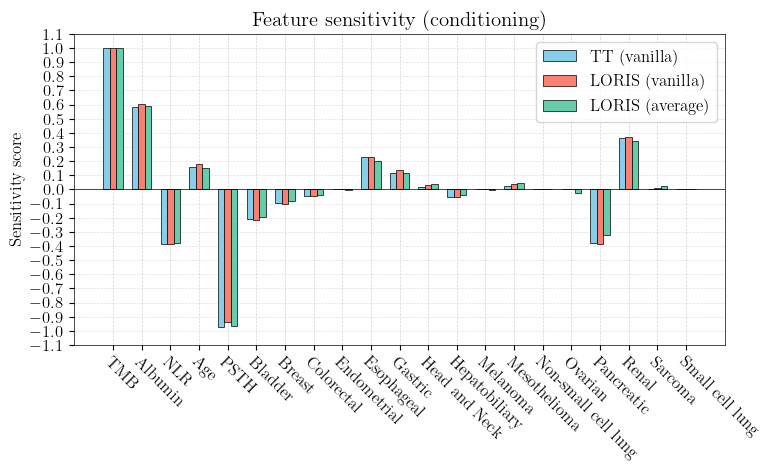

In [28]:
# Bar plot setup
x = torch.arange(len(featuresNA)) * 2  # label locations
width = 0.45  # width of the bars

fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar(x - width, tt_scores, width, 
               label='TT (vanilla)', color='skyblue', edgecolor='black', linewidth=0.5)
bars2 = ax.bar(x, lr_van_scores, width, 
               label='LORIS (vanilla)', color='salmon', edgecolor='black', linewidth=0.5)
bars3 = ax.bar(x + width, lr_avg_scores, width, 
               label='LORIS (average)', color='mediumaquamarine', edgecolor='black', linewidth=0.5)

# Axes settings
# ax.set_xlabel('Feature')
ax.set_ylabel('Sensitivity score')
ax.set_title('Feature sensitivity (conditioning)')
ax.set_xticks(x)
ax.set_xticklabels([plot_labels[feat] for feat in featuresNA],
                   rotation=-45, ha='left', rotation_mode='anchor')
ax.legend(loc='upper right')

# Horizontal line at y=0
ax.axhline(0, color='black', linewidth=0.5)

# Vertical lines at each x-tick
for xpos in x:
    ax.axvline(x=xpos, color='lightgrey',
               linestyle='--', linewidth=0.5, alpha=1, zorder=-1)

# Y-ticks every 0.1
ymin, ymax = ax.get_ylim()
yticks = np.arange(round(ymin,1), round(ymax+0.1,1), 0.1)
ax.set_yticks(yticks)

# Horizontal grey lines at each y-tick
for y in yticks:
    ax.axhline(y=y, color='lightgrey',
               linestyle='--', linewidth=0.5, alpha=0.7, zorder=-1)

plt.tight_layout()
plt.savefig(os.path.join(figures_dir, 'feat_sensitivity_cond.pdf'),
            bbox_inches='tight')
plt.show()

Marginalizing variables

In [29]:
# Collect sensitivity scores
lr_van_scores = []
lr_avg_scores = []
tt_scores = []
for feat in featuresNA:
    lr_van_scores.append(feature_sensitivity_cond(feat, lr_van_model, xt_train,
                                                  featuresNA, scalers_train))
    lr_avg_scores.append(feature_sensitivity_cond(feat, lr_avg_model, xt_train,
                                                  featuresNA, scalers_train))
    tt_scores.append(feature_sensitivity_marg(feature=feat,
                                              mps=mps,
                                              in_features=featuresNA,
                                              out_feature=phenoNA,
                                              num_features=numeric_featuresNA,
                                              n_classes=n_classes,
                                              phys_dim=phys_dim,
                                              x_train=xt_train,
                                              discr_steps=int(1e5),
                                              scalers_dict=scalers_train))

lr_van_scores = torch.stack(lr_van_scores, dim=0)
lr_van_scores = lr_van_scores / lr_van_scores.abs().max()

lr_avg_scores = torch.stack(lr_avg_scores, dim=0)
lr_avg_scores = lr_avg_scores / lr_avg_scores.abs().max()

tt_scores = torch.tensor(tt_scores)
tt_scores = tt_scores / tt_scores.abs().max()

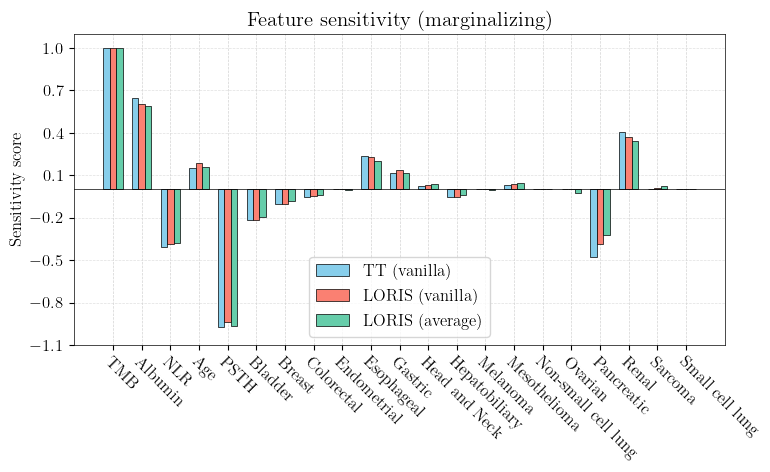

In [30]:
# Bar plot setup
x = torch.arange(len(featuresNA)) * 2  # label locations
width = 0.45  # width of the bars

fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar(x - width, tt_scores, width, 
               label='TT (vanilla)', color='skyblue', edgecolor='black', linewidth=0.5)
bars2 = ax.bar(x, lr_van_scores, width, 
               label='LORIS (vanilla)', color='salmon', edgecolor='black', linewidth=0.5)
bars3 = ax.bar(x + width, lr_avg_scores, width, 
               label='LORIS (average)', color='mediumaquamarine', edgecolor='black', linewidth=0.5)

# Axes settings
# ax.set_xlabel('Feature')
ax.set_ylabel('Sensitivity score')
ax.set_title('Feature sensitivity (marginalizing)')
ax.set_xticks(x)
ax.set_xticklabels([plot_labels[feat] for feat in featuresNA],
                   rotation=-45, ha='left', rotation_mode='anchor')
ax.legend(loc='lower center')

# Horizontal line at y=0
ax.axhline(0, color='black', linewidth=0.5)

# Vertical lines at each x-tick
for xpos in x:
    ax.axvline(x=xpos, color='lightgrey',
               linestyle='--', linewidth=0.5, alpha=1, zorder=-1)

# Y-ticks every 0.1
ymin, ymax = ax.get_ylim()
yticks = np.arange(round(ymin,1), round(ymax+0.1,1), 0.3)
ax.set_yticks(yticks)

# Horizontal grey lines at each y-tick
for y in yticks:
    ax.axhline(y=y, color='lightgrey',
               linestyle='--', linewidth=0.5, alpha=0.7, zorder=-1)

plt.tight_layout()
plt.savefig(os.path.join(figures_dir, 'feat_sensitivity_marg.pdf'),
            bbox_inches='tight')
plt.show()

Recovering LR coefficiets from the TT

In [31]:
# Collect sensitivity scores
lr_van_scores = []
lr_avg_scores = []
tt_scores = []
for feat in featuresNA:
    lr_van_scores.append(feature_sensitivity_coeffs(feat, lr_van_model, xt_train,
                                                    featuresNA, scalers_train))
    lr_avg_scores.append(feature_sensitivity_coeffs(feat, lr_avg_model, xt_train,
                                                    featuresNA, scalers_train))
    tt_scores.append(feature_sensitivity_coeffs(feat, tt_model, xt_train,
                                                featuresNA, scalers_train))


lr_van_scores = torch.stack(lr_van_scores, dim=0)
lr_van_scores = lr_van_scores / lr_van_scores.abs().max()

lr_avg_scores = torch.stack(lr_avg_scores, dim=0)
lr_avg_scores = lr_avg_scores / lr_avg_scores.abs().max()

tt_scores = torch.stack(tt_scores, dim=0)
tt_scores = tt_scores / tt_scores.abs().max()

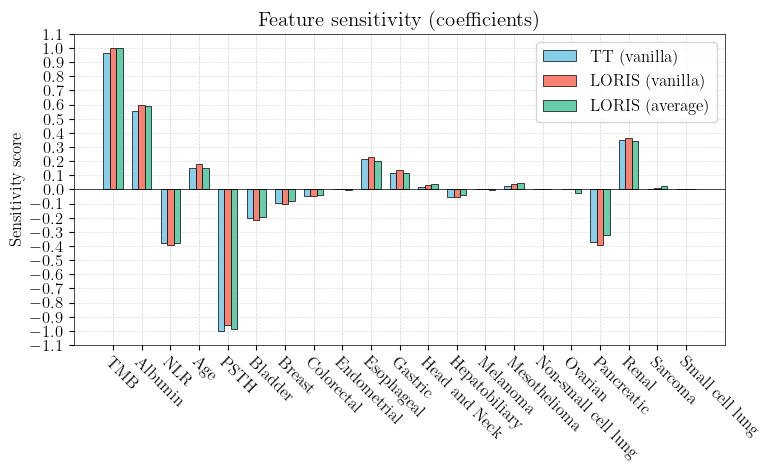

In [32]:
# Bar plot setup
x = torch.arange(len(featuresNA)) * 2  # label locations
width = 0.45  # width of the bars

fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar(x - width, tt_scores, width, 
               label='TT (vanilla)', color='skyblue', edgecolor='black', linewidth=0.5)
bars2 = ax.bar(x, lr_van_scores, width, 
               label='LORIS (vanilla)', color='salmon', edgecolor='black', linewidth=0.5)
bars3 = ax.bar(x + width, lr_avg_scores, width, 
               label='LORIS (average)', color='mediumaquamarine', edgecolor='black', linewidth=0.5)

# Axes settings
# ax.set_xlabel('Feature')
ax.set_ylabel('Sensitivity score')
ax.set_title('Feature sensitivity (coefficients)')
ax.set_xticks(x)
ax.set_xticklabels([plot_labels[feat] for feat in featuresNA],
                   rotation=-45, ha='left', rotation_mode='anchor')
ax.legend(loc='upper right')

# Horizontal line at y=0
ax.axhline(0, color='black', linewidth=0.5)

# Vertical lines at each x-tick
for xpos in x:
    ax.axvline(x=xpos, color='lightgrey',
               linestyle='--', linewidth=0.5, alpha=1, zorder=-1)

# Y-ticks every 0.1
ymin, ymax = ax.get_ylim()
yticks = np.arange(round(ymin,1), round(ymax+0.1,1), 0.1)
ax.set_yticks(yticks)

# Horizontal grey lines at each y-tick
for y in yticks:
    ax.axhline(y=y, color='lightgrey',
               linestyle='--', linewidth=0.5, alpha=0.7, zorder=-1)

plt.tight_layout()
plt.savefig(os.path.join(figures_dir, 'feat_sensitivity_coeffs.pdf'),
            bbox_inches='tight')
plt.show()

Compare LR measures

In [33]:
# Collect sensitivity scores
lr_van_cond = []
lr_van_coeffs = []
tt_scores = []
for feat in featuresNA:
    lr_van_cond.append(feature_sensitivity_cond(feat, lr_van_model, xt_train,
                                                featuresNA, scalers_train))
    lr_van_coeffs.append(feature_sensitivity_coeffs(feat, lr_van_model, xt_train,
                                                    featuresNA, scalers_train))
    tt_scores.append(feature_sensitivity_marg(feature=feat,
                                              mps=mps,
                                              in_features=featuresNA,
                                              out_feature=phenoNA,
                                              num_features=numeric_featuresNA,
                                              n_classes=n_classes,
                                              phys_dim=phys_dim,
                                              x_train=xt_train,
                                              discr_steps=int(1e5),
                                              scalers_dict=scalers_train))

lr_van_cond = torch.stack(lr_van_cond, dim=0)
lr_van_cond = lr_van_cond / lr_van_cond.abs().max()

lr_van_coeffs = torch.stack(lr_van_coeffs, dim=0)
lr_van_coeffs = lr_van_coeffs / lr_van_coeffs.abs().max()

tt_scores = torch.tensor(tt_scores)
tt_scores = tt_scores / tt_scores.abs().max()

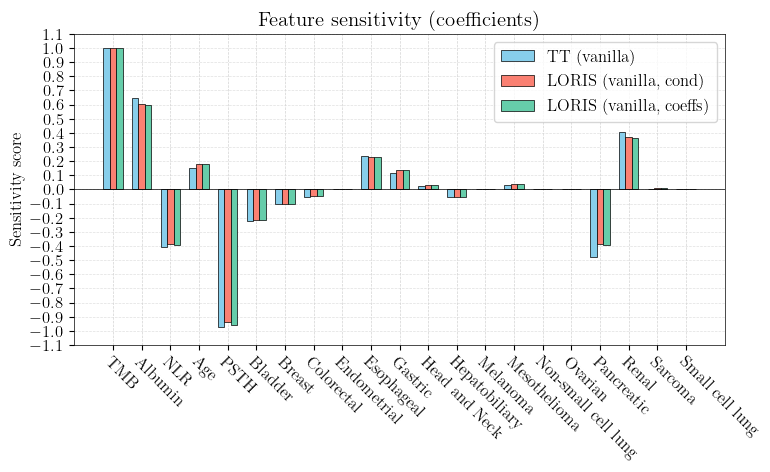

In [34]:
# Bar plot setup
x = torch.arange(len(featuresNA)) * 2  # label locations
width = 0.45  # width of the bars

fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar(x - width, tt_scores, width, 
               label='TT (vanilla)', color='skyblue', edgecolor='black', linewidth=0.5)
bars2 = ax.bar(x, lr_van_cond, width, 
               label='LORIS (vanilla, cond)', color='salmon', edgecolor='black', linewidth=0.5)
bars3 = ax.bar(x + width, lr_van_coeffs, width, 
               label='LORIS (vanilla, coeffs)', color='mediumaquamarine', edgecolor='black', linewidth=0.5)

# Axes settings
# ax.set_xlabel('Feature')
ax.set_ylabel('Sensitivity score')
ax.set_title('Feature sensitivity (coefficients)')
ax.set_xticks(x)
ax.set_xticklabels([plot_labels[feat] for feat in featuresNA],
                   rotation=-45, ha='left', rotation_mode='anchor')
ax.legend(loc='upper right')

# Horizontal line at y=0
ax.axhline(0, color='black', linewidth=0.5)

# Vertical lines at each x-tick
for xpos in x:
    ax.axvline(x=xpos, color='lightgrey',
               linestyle='--', linewidth=0.5, alpha=1, zorder=-1)

# Y-ticks every 0.1
ymin, ymax = ax.get_ylim()
yticks = np.arange(round(ymin,1), round(ymax+0.1,1), 0.1)
ax.set_yticks(yticks)

# Horizontal grey lines at each y-tick
for y in yticks:
    ax.axhline(y=y, color='lightgrey',
               linestyle='--', linewidth=0.5, alpha=0.7, zorder=-1)

plt.tight_layout()
plt.savefig(os.path.join(figures_dir, 'feat_sensitivity_compare.pdf'),
            bbox_inches='tight')
plt.show()

In [35]:
# Collect sensitivity scores
lr_van_cond = []
lr_van_coeffs = []
tt_scores = []
for feat in featuresNA:
    lr_van_cond.append(feature_sensitivity_cond(feat, lr_van_model, xt_train,
                                                featuresNA, scalers_train))
    lr_van_coeffs.append(feature_sensitivity_coeffs(feat, lr_van_model, xt_train,
                                                    featuresNA, scalers_train))
    tt_scores.append(feature_sensitivity_cond(feat, tt_model, xt_train,
                                              featuresNA, scalers_train))

lr_van_cond = torch.stack(lr_van_cond, dim=0)
lr_van_cond = lr_van_cond / lr_van_cond.abs().max()

lr_van_coeffs = torch.stack(lr_van_coeffs, dim=0)
lr_van_coeffs = lr_van_coeffs / lr_van_coeffs.abs().max()

tt_scores = torch.stack(tt_scores, dim=0)
tt_scores = tt_scores / tt_scores.abs().max()

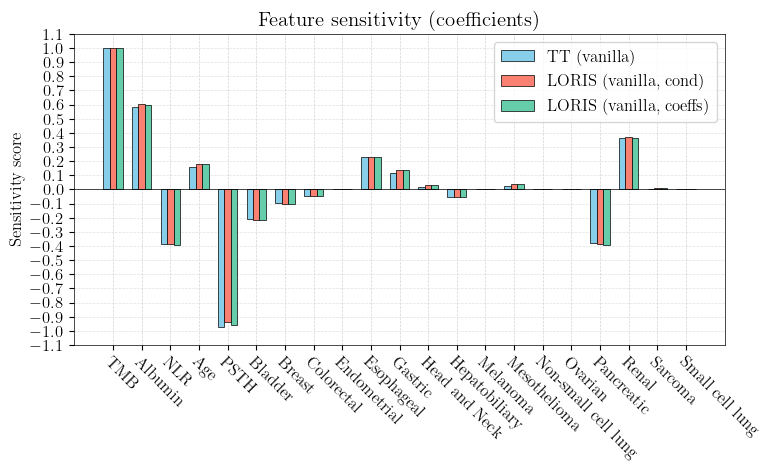

In [36]:
# Bar plot setup
x = torch.arange(len(featuresNA)) * 2  # label locations
width = 0.45  # width of the bars

fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar(x - width, tt_scores, width, 
               label='TT (vanilla)', color='skyblue', edgecolor='black', linewidth=0.5)
bars2 = ax.bar(x, lr_van_cond, width, 
               label='LORIS (vanilla, cond)', color='salmon', edgecolor='black', linewidth=0.5)
bars3 = ax.bar(x + width, lr_van_coeffs, width, 
               label='LORIS (vanilla, coeffs)', color='mediumaquamarine', edgecolor='black', linewidth=0.5)

# Axes settings
# ax.set_xlabel('Feature')
ax.set_ylabel('Sensitivity score')
ax.set_title('Feature sensitivity (coefficients)')
ax.set_xticks(x)
ax.set_xticklabels([plot_labels[feat] for feat in featuresNA],
                   rotation=-45, ha='left', rotation_mode='anchor')
ax.legend(loc='upper right')

# Horizontal line at y=0
ax.axhline(0, color='black', linewidth=0.5)

# Vertical lines at each x-tick
for xpos in x:
    ax.axvline(x=xpos, color='lightgrey',
               linestyle='--', linewidth=0.5, alpha=1, zorder=-1)

# Y-ticks every 0.1
ymin, ymax = ax.get_ylim()
yticks = np.arange(round(ymin,1), round(ymax+0.1,1), 0.1)
ax.set_yticks(yticks)

# Horizontal grey lines at each y-tick
for y in yticks:
    ax.axhline(y=y, color='lightgrey',
               linestyle='--', linewidth=0.5, alpha=0.7, zorder=-1)

plt.tight_layout()
plt.savefig(os.path.join(figures_dir, 'feat_sensitivity_compare.pdf'),
            bbox_inches='tight')
plt.show()

### Feature sensitivity by CancerType

Conditioning on mean values

In [37]:
aux_featuresNA = ['TMB', 'Albumin', 'NLR', 'Age', 'Systemic_therapy_history']

cancer_features = ['CancerType1', 'CancerType2', 'CancerType3', 'CancerType4',
                   'CancerType5', 'CancerType6', 'CancerType7', 'CancerType8',
                   'CancerType9', 'CancerType10', 'CancerType11', 'CancerType12',
                   'CancerType13', 'CancerType14', 'CancerType15', 'CancerType16']

mps.reset()
mps.unset_data_nodes()

scores_by_cancer = []
train_baccs = []
for cancer_idx in range(16):
    # print(cancer_idx)
    cancer_scores = []
    
    # print(feat)
    aux_mps, aux_xt_train, aux_yt_train, train_bal_acc = get_cancertype_mps(
        mps, phys_dim, cancer_idx, xt_train, yt_train, scalers_train)
    train_baccs.append(train_bal_acc)
    
    # print(aux_mps.tensors)
    
    @torch.no_grad()
    def aux_tt_model(data):
        result = aux_mps(embedding(data)).pow(2)
        result = result / result.sum(dim=1, keepdim=True)
        return result
        
    for feat in aux_featuresNA:
        # print(feat)
        cancer_scores.append(feature_sensitivity_cond(feat, aux_tt_model,
                                                      aux_xt_train, aux_featuresNA,
                                                      scalers_train))
    
    cancer_scores = torch.stack(cancer_scores, dim=0)
    cancer_scores = cancer_scores / cancer_scores.abs().max()
    
    # print(cancer_scores)
    scores_by_cancer.append(cancer_scores)
    # print()
    # print()

Model accuracy: Train: 0.75
Model balanced accuracy: Train: 0.62
Correct predicitons
Train:
    Class 0: 44 / 53 (0.8302)
    Class 1: 5 / 12 (0.4167)

Model accuracy: Train: 0.92
Model balanced accuracy: Train: 0.50
Correct predicitons
Train:
    Class 0: 11 / 11 (1.0000)
    Class 1: 0 / 1 (0.0000)

Model accuracy: Train: 0.86
Model balanced accuracy: Train: 0.86
Correct predicitons
Train:
    Class 0: 18 / 21 (0.8571)
    Class 1: 6 / 7 (0.8571)

Model accuracy: Train: 0.78
Model balanced accuracy: Train: 0.71
Correct predicitons
Train:
    Class 0: 17 / 20 (0.8500)
    Class 1: 4 / 7 (0.5714)

Model accuracy: Train: 0.62
Model balanced accuracy: Train: 0.66
Correct predicitons
Train:
    Class 0: 6 / 14 (0.4286)
    Class 1: 9 / 10 (0.9000)

Model accuracy: Train: 0.84
Model balanced accuracy: Train: 0.84
Correct predicitons
Train:
    Class 0: 22 / 27 (0.8148)
    Class 1: 14 / 16 (0.8750)

Model accuracy: Train: 0.79
Model balanced accuracy: Train: 0.61
Correct predicitons
Train:

/export/anaconda3/envs/loris/lib/python3.11/site-packages/sklearn/metrics/_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


Model accuracy: Train: 0.79
Model balanced accuracy: Train: 0.65
Correct predicitons
Train:
    Class 0: 23 / 25 (0.9200)
    Class 1: 3 / 8 (0.3750)

Model accuracy: Train: 0.71
Model balanced accuracy: Train: 0.50
Correct predicitons
Train:
    Class 0: 23 / 26 (0.8846)
    Class 1: 1 / 8 (0.1250)



In [38]:
scores_by_cancer

[tensor([ 1.0000,  0.5719, -0.3641,  0.1500, -0.8870]),
 tensor([ 1.0000,  0.5707, -0.3614,  0.1494, -0.8766]),
 tensor([ 1.0000,  0.5784, -0.3784,  0.1535, -0.9386]),
 tensor([ 1.0000,  0.5821, -0.3865,  0.1555, -0.9679]),
 tensor([ 0.8957,  0.5359, -0.3810,  0.1474, -1.0000]),
 tensor([ 0.9794,  0.5755, -0.3919,  0.1553, -1.0000]),
 tensor([ 1.0000,  0.5832, -0.3889,  0.1561, -0.9764]),
 tensor([ 1.0000,  0.5786, -0.3789,  0.1536, -0.9405]),
 tensor([ 1.0000,  0.5821, -0.3865,  0.1555, -0.9679]),
 tensor([ 1.0000,  0.5846, -0.3920,  0.1568, -0.9878]),
 tensor([ 1.0000,  0.5821, -0.3865,  0.1555, -0.9679]),
 tensor([ 1.0000,  0.5821, -0.3865,  0.1555, -0.9679]),
 tensor([ 1.0000,  0.5308, -0.2771,  0.1283, -0.5771]),
 tensor([ 0.8907,  0.5353, -0.3820,  0.1476, -1.0000]),
 tensor([ 1.0000,  0.5821, -0.3865,  0.1555, -0.9679]),
 tensor([ 1.0000,  0.5821, -0.3865,  0.1555, -0.9679])]

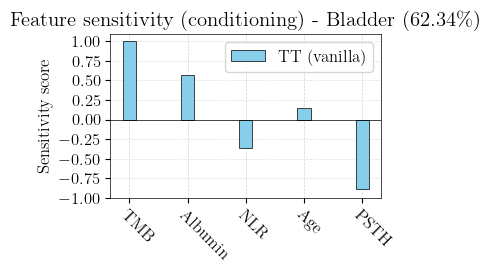

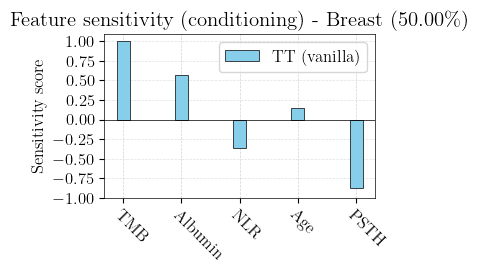

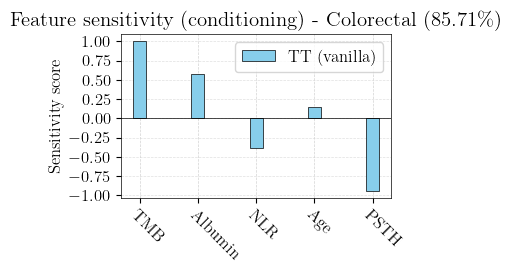

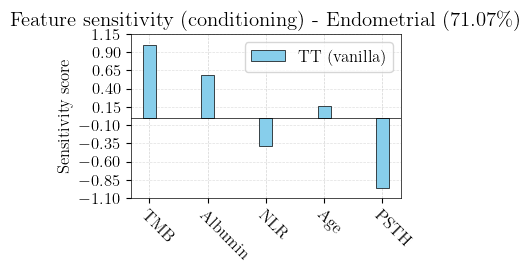

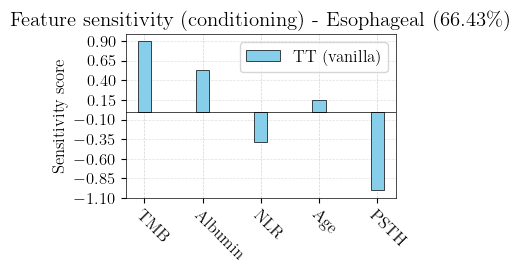

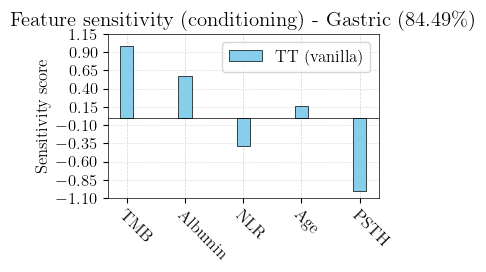

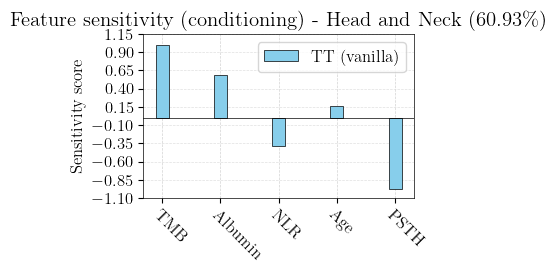

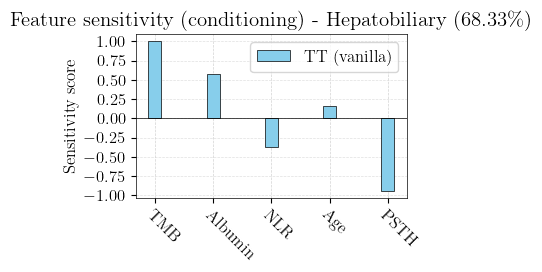

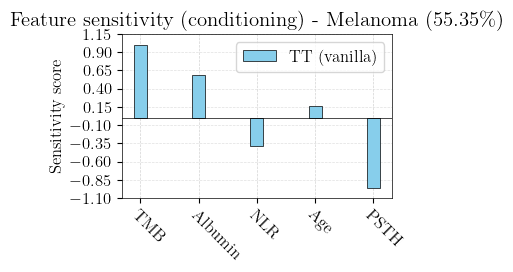

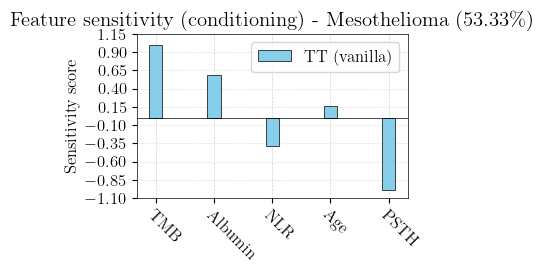

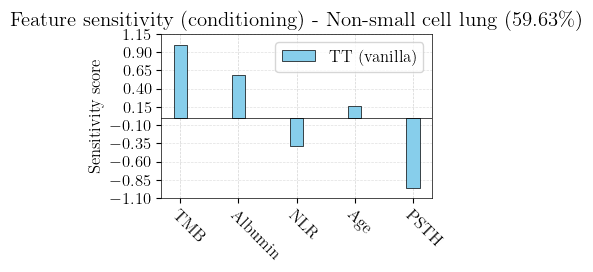

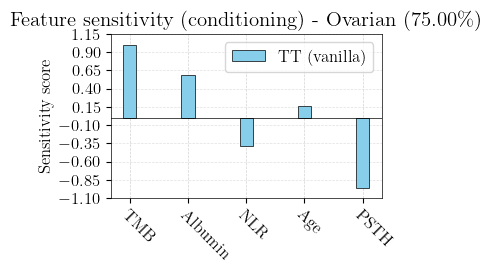

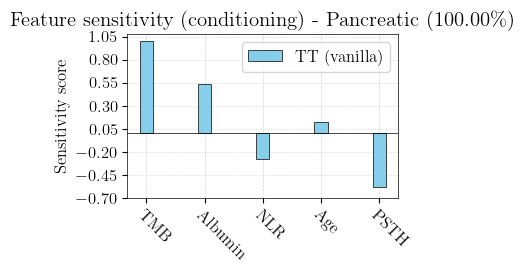

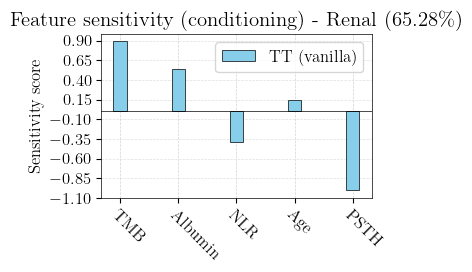

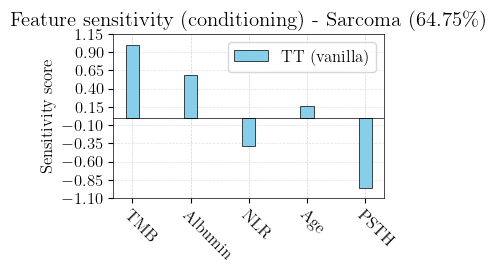

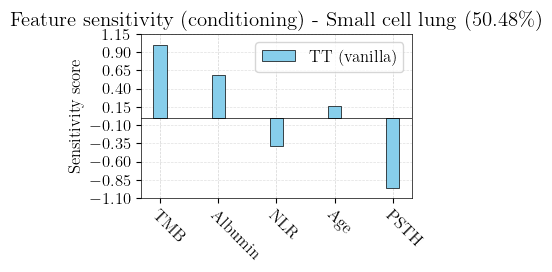

In [39]:
for cancer_idx in range(16):
    # Bar plot setup
    x = torch.arange(len(aux_featuresNA)) * 2  # label locations
    width = 0.45  # width of the bars

    fig, ax = plt.subplots(figsize=(4, 3))
    bars = ax.bar(x, scores_by_cancer[cancer_idx], width, 
                  label='TT (vanilla)', color='skyblue', edgecolor='black', linewidth=0.5)

    # Axes settings
    # ax.set_xlabel('Feature')
    ax.set_ylabel('Sensitivity score')
    ax.set_title(f'Feature sensitivity (conditioning) - '
                 f'{list(plot_labels.values())[cancer_idx + 5]} '
                 f'({train_baccs[cancer_idx] * 100:.2f}\%)')
    ax.set_xticks(x)
    ax.set_xticklabels([plot_labels[feat] for feat in aux_featuresNA],
                    rotation=-45, ha='left', rotation_mode='anchor')
    ax.legend(loc='upper right')

    # Horizontal line at y=0
    ax.axhline(0, color='black', linewidth=0.5)

    # Vertical lines at each x-tick
    for xpos in x:
        ax.axvline(x=xpos, color='lightgrey',
                linestyle='--', linewidth=0.5, alpha=1, zorder=-1)

    # Y-ticks every 0.1
    ymin, ymax = ax.get_ylim()
    yticks = np.arange(round(ymin,1), round(ymax+0.1,1), 0.25)
    ax.set_yticks(yticks)

    # Horizontal grey lines at each y-tick
    for y in yticks:
        ax.axhline(y=y, color='lightgrey',
                linestyle='--', linewidth=0.5, alpha=0.7, zorder=-1)

    plt.tight_layout()
    # plt.savefig(os.path.join(figures_dir, 'feat_sensitivity_coeffs.pdf'),
                # bbox_inches='tight')
    plt.show()

Marginalizing variables

In [40]:
aux_featuresNA = ['TMB', 'Albumin', 'NLR', 'Age', 'Systemic_therapy_history']

cancer_features = ['CancerType1', 'CancerType2', 'CancerType3', 'CancerType4',
                   'CancerType5', 'CancerType6', 'CancerType7', 'CancerType8',
                   'CancerType9', 'CancerType10', 'CancerType11', 'CancerType12',
                   'CancerType13', 'CancerType14', 'CancerType15', 'CancerType16']

mps.reset()
mps.unset_data_nodes()

scores_by_cancer = []
train_baccs = []
for cancer_idx in range(16):
    # print(cancer_idx)
    cancer_scores = []
    
    # print(feat)
    aux_mps, aux_xt_train, aux_yt_train, train_bal_acc = get_cancertype_mps(
        mps, phys_dim, cancer_idx, xt_train, yt_train, scalers_train)
    train_baccs.append(train_bal_acc)
    
    # print(aux_mps.tensors)
    
    @torch.no_grad()
    def aux_tt_model(data):
        result = aux_mps(embedding(data)).pow(2)
        result = result / result.sum(dim=1, keepdim=True)
        return result
        
    for feat in aux_featuresNA:
        # print(feat)
        cancer_scores.append(feature_sensitivity_marg(feature=feat,
                                                      mps=aux_mps,
                                                      in_features=aux_featuresNA,
                                                      out_feature=phenoNA,
                                                      num_features=numeric_featuresNA,
                                                      n_classes=n_classes,
                                                      phys_dim=phys_dim,
                                                      x_train=aux_xt_train,
                                                      discr_steps=int(1e5),
                                                      scalers_dict=scalers_train))
    
    cancer_scores = torch.tensor(cancer_scores)
    cancer_scores = cancer_scores / cancer_scores.abs().max()
    
    # print(cancer_scores)
    scores_by_cancer.append(cancer_scores)
    # print()
    # print()

Model accuracy: Train: 0.75
Model balanced accuracy: Train: 0.62
Correct predicitons
Train:
    Class 0: 44 / 53 (0.8302)
    Class 1: 5 / 12 (0.4167)

Model accuracy: Train: 0.92
Model balanced accuracy: Train: 0.50
Correct predicitons
Train:
    Class 0: 11 / 11 (1.0000)
    Class 1: 0 / 1 (0.0000)

Model accuracy: Train: 0.86
Model balanced accuracy: Train: 0.86
Correct predicitons
Train:
    Class 0: 18 / 21 (0.8571)
    Class 1: 6 / 7 (0.8571)

Model accuracy: Train: 0.78
Model balanced accuracy: Train: 0.71
Correct predicitons
Train:
    Class 0: 17 / 20 (0.8500)
    Class 1: 4 / 7 (0.5714)

Model accuracy: Train: 0.62
Model balanced accuracy: Train: 0.66
Correct predicitons
Train:
    Class 0: 6 / 14 (0.4286)
    Class 1: 9 / 10 (0.9000)

Model accuracy: Train: 0.84
Model balanced accuracy: Train: 0.84
Correct predicitons
Train:
    Class 0: 22 / 27 (0.8148)
    Class 1: 14 / 16 (0.8750)

Model accuracy: Train: 0.79
Model balanced accuracy: Train: 0.61
Correct predicitons
Train:

/export/anaconda3/envs/loris/lib/python3.11/site-packages/sklearn/metrics/_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


Model accuracy: Train: 0.79
Model balanced accuracy: Train: 0.65
Correct predicitons
Train:
    Class 0: 23 / 25 (0.9200)
    Class 1: 3 / 8 (0.3750)

Model accuracy: Train: 0.71
Model balanced accuracy: Train: 0.50
Correct predicitons
Train:
    Class 0: 23 / 26 (0.8846)
    Class 1: 1 / 8 (0.1250)



In [41]:
scores_by_cancer

[tensor([ 1.0000,  0.5096, -0.3411,  0.1325, -0.9512]),
 tensor([ 1.0000,  0.5700, -0.3593,  0.1524, -0.9976]),
 tensor([ 1.0000,  0.5954, -0.4044,  0.1542, -0.9829]),
 tensor([ 1.0000,  0.4988, -0.3558,  0.1386, -0.9285]),
 tensor([ 0.9758,  0.4487, -0.3453,  0.1334, -1.0000]),
 tensor([ 1.0000,  0.5029, -0.3599,  0.1406, -0.9138]),
 tensor([ 1.0000,  0.5928, -0.3872,  0.1503, -0.8604]),
 tensor([ 1.0000,  0.5415, -0.3673,  0.1413, -0.9449]),
 tensor([ 1.0000,  0.4951, -0.3283,  0.1287, -0.9290]),
 tensor([ 1.0000,  0.6109, -0.3667,  0.1389, -0.6414]),
 tensor([ 1.0000,  0.4912, -0.3290,  0.1288, -0.9286]),
 tensor([ 1.0000,  0.5679, -0.3749,  0.1478, -0.8933]),
 tensor([ 0.3324,  0.3737,  0.0979, -0.1899,  1.0000]),
 tensor([ 1.0000,  0.6232, -0.3999,  0.1600, -0.9400]),
 tensor([ 1.0000,  0.6227, -0.3785,  0.1450, -0.7161]),
 tensor([ 1.0000,  0.5867, -0.3900,  0.1513, -0.8836])]

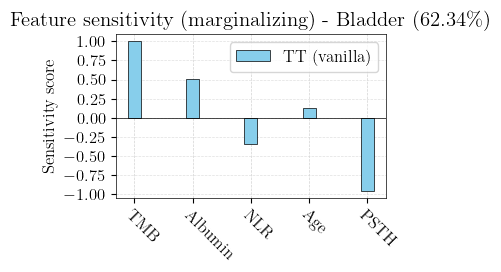

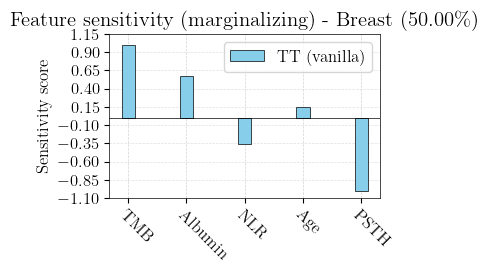

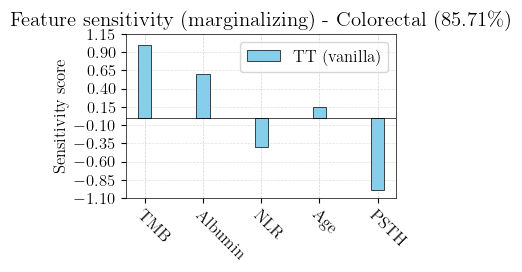

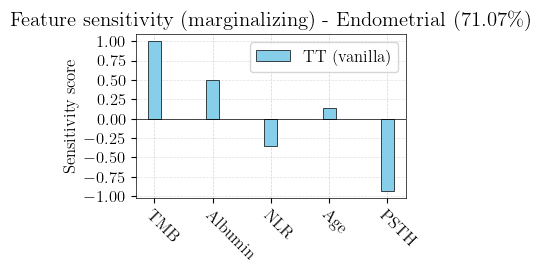

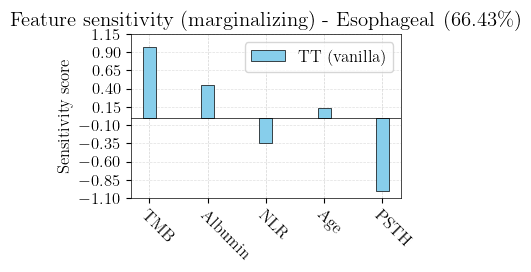

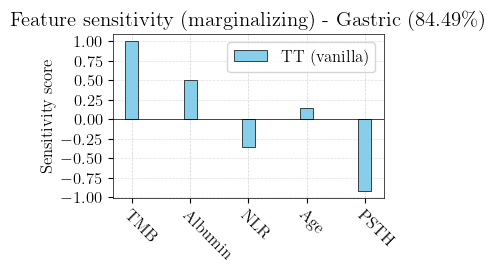

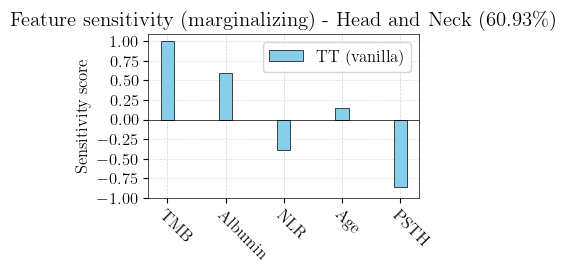

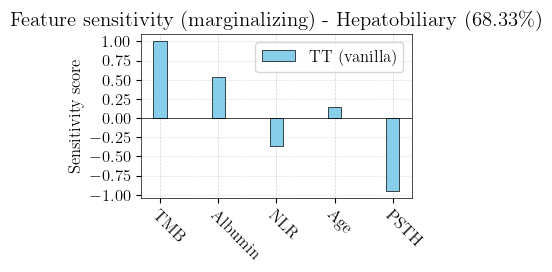

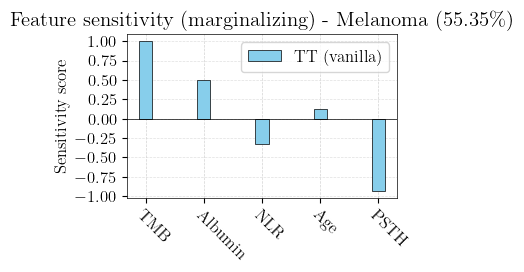

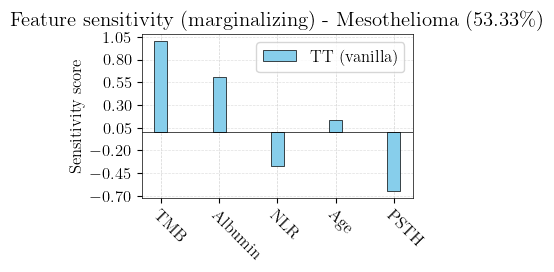

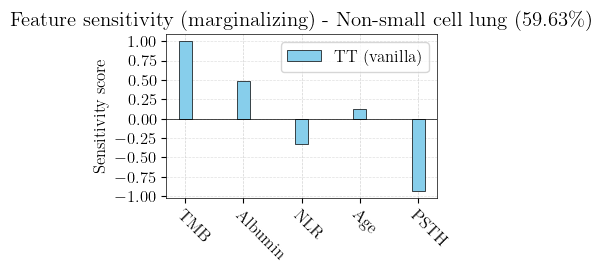

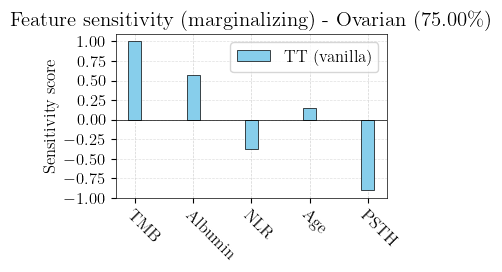

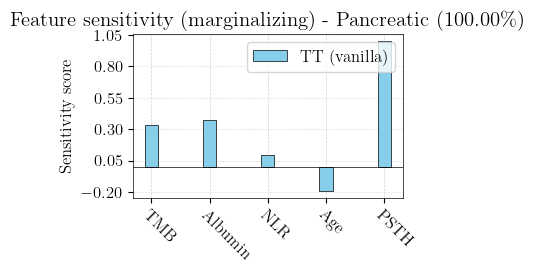

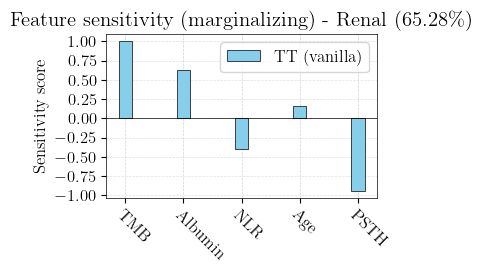

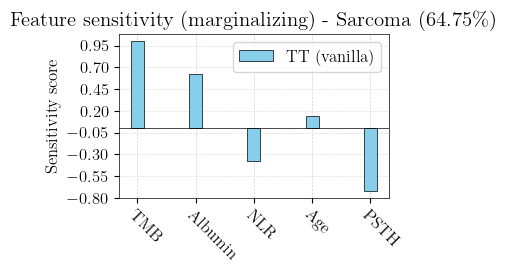

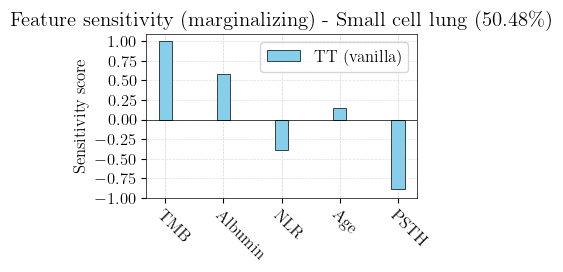

In [42]:
for cancer_idx in range(16):
    # Bar plot setup
    x = torch.arange(len(aux_featuresNA)) * 2  # label locations
    width = 0.45  # width of the bars

    fig, ax = plt.subplots(figsize=(4, 3))
    bars = ax.bar(x, scores_by_cancer[cancer_idx], width, 
                  label='TT (vanilla)', color='skyblue', edgecolor='black', linewidth=0.5)

    # Axes settings
    # ax.set_xlabel('Feature')
    ax.set_ylabel('Sensitivity score')
    ax.set_title(f'Feature sensitivity (marginalizing) - '
                 f'{list(plot_labels.values())[cancer_idx + 5]} '
                 f'({train_baccs[cancer_idx] * 100:.2f}\%)')
    ax.set_xticks(x)
    ax.set_xticklabels([plot_labels[feat] for feat in aux_featuresNA],
                    rotation=-45, ha='left', rotation_mode='anchor')
    ax.legend(loc='upper right')

    # Horizontal line at y=0
    ax.axhline(0, color='black', linewidth=0.5)

    # Vertical lines at each x-tick
    for xpos in x:
        ax.axvline(x=xpos, color='lightgrey',
                linestyle='--', linewidth=0.5, alpha=1, zorder=-1)

    # Y-ticks every 0.1
    ymin, ymax = ax.get_ylim()
    yticks = np.arange(round(ymin,1), round(ymax+0.1,1), 0.25)
    ax.set_yticks(yticks)

    # Horizontal grey lines at each y-tick
    for y in yticks:
        ax.axhline(y=y, color='lightgrey',
                linestyle='--', linewidth=0.5, alpha=0.7, zorder=-1)

    plt.tight_layout()
    # plt.savefig(os.path.join(figures_dir, 'feat_sensitivity_coeffs.pdf'),
                # bbox_inches='tight')
    plt.show()

Recovering LR coefficiets from the TT

In [43]:
aux_featuresNA = ['TMB', 'Albumin', 'NLR', 'Age', 'Systemic_therapy_history']

cancer_features = ['CancerType1', 'CancerType2', 'CancerType3', 'CancerType4',
                   'CancerType5', 'CancerType6', 'CancerType7', 'CancerType8',
                   'CancerType9', 'CancerType10', 'CancerType11', 'CancerType12',
                   'CancerType13', 'CancerType14', 'CancerType15', 'CancerType16']

mps.reset()
mps.unset_data_nodes()

scores_by_cancer = []
train_baccs = []
for cancer_idx in range(16):
    # print(cancer_idx)
    cancer_scores = []
    
    # print(feat)
    aux_mps, aux_xt_train, aux_yt_train, train_bal_acc = get_cancertype_mps(
        mps, phys_dim, cancer_idx, xt_train, yt_train, scalers_train)
    train_baccs.append(train_bal_acc)
    
    # print(aux_mps.tensors)
    
    @torch.no_grad()
    def aux_tt_model(data):
        result = aux_mps(embedding(data)).pow(2)
        result = result / result.sum(dim=1, keepdim=True)
        return result
        
    for feat in aux_featuresNA:
        # print(feat)
        cancer_scores.append(feature_sensitivity_coeffs(feat, aux_tt_model,
                                                        aux_xt_train, aux_featuresNA,
                                                        scalers_train))
    
    cancer_scores = torch.stack(cancer_scores, dim=0)
    cancer_scores = cancer_scores / cancer_scores.abs().max()
    
    # print(cancer_scores)
    scores_by_cancer.append(cancer_scores)
    # print()
    # print()

Model accuracy: Train: 0.75
Model balanced accuracy: Train: 0.62
Correct predicitons
Train:
    Class 0: 44 / 53 (0.8302)
    Class 1: 5 / 12 (0.4167)

Model accuracy: Train: 0.92
Model balanced accuracy: Train: 0.50
Correct predicitons
Train:
    Class 0: 11 / 11 (1.0000)
    Class 1: 0 / 1 (0.0000)

Model accuracy: Train: 0.86
Model balanced accuracy: Train: 0.86
Correct predicitons
Train:
    Class 0: 18 / 21 (0.8571)
    Class 1: 6 / 7 (0.8571)

Model accuracy: Train: 0.78
Model balanced accuracy: Train: 0.71
Correct predicitons
Train:
    Class 0: 17 / 20 (0.8500)
    Class 1: 4 / 7 (0.5714)

Model accuracy: Train: 0.62
Model balanced accuracy: Train: 0.66
Correct predicitons
Train:
    Class 0: 6 / 14 (0.4286)
    Class 1: 9 / 10 (0.9000)

Model accuracy: Train: 0.84
Model balanced accuracy: Train: 0.84
Correct predicitons
Train:
    Class 0: 22 / 27 (0.8148)
    Class 1: 14 / 16 (0.8750)

Model accuracy: Train: 0.79
Model balanced accuracy: Train: 0.61
Correct predicitons
Train:

/export/anaconda3/envs/loris/lib/python3.11/site-packages/sklearn/metrics/_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


In [44]:
scores_by_cancer

[tensor([ 0.8886,  0.5221, -0.3702,  0.1424, -1.0000]),
 tensor([ 0.8857,  0.5206, -0.3696,  0.1421, -1.0000]),
 tensor([ 0.9385,  0.5457, -0.3771,  0.1473, -1.0000]),
 tensor([ 0.9621,  0.5567, -0.3802,  0.1495, -1.0000]),
 tensor([ 1.0000,  0.5645, -0.3649,  0.1479, -0.9255]),
 tensor([ 1.0000,  0.5726, -0.3816,  0.1521, -0.9865]),
 tensor([ 0.9690,  0.5598, -0.3811,  0.1501, -1.0000]),
 tensor([ 0.9398,  0.5463, -0.3773,  0.1474, -1.0000]),
 tensor([ 0.9621,  0.5567, -0.3802,  0.1495, -1.0000]),
 tensor([ 0.9782,  0.5640, -0.3822,  0.1509, -1.0000]),
 tensor([ 0.9621,  0.5567, -0.3802,  0.1495, -1.0000]),
 tensor([ 0.9621,  0.5567, -0.3802,  0.1495, -1.0000]),
 tensor([ 0.5766,  0.3594, -0.3056,  0.1051, -1.0000]),
 tensor([ 1.0000,  0.5633, -0.3633,  0.1474, -0.9219]),
 tensor([ 0.9621,  0.5567, -0.3802,  0.1495, -1.0000]),
 tensor([ 0.9621,  0.5567, -0.3802,  0.1495, -1.0000])]

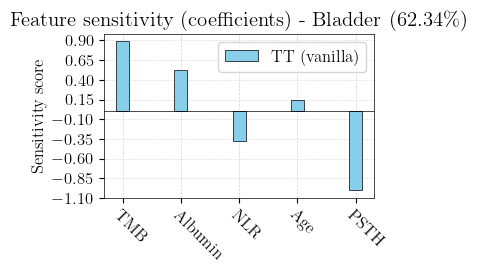

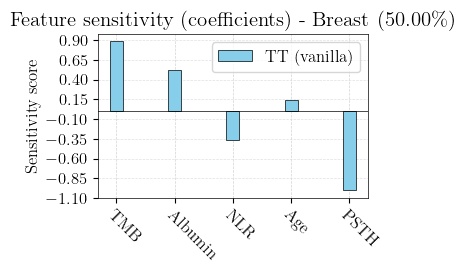

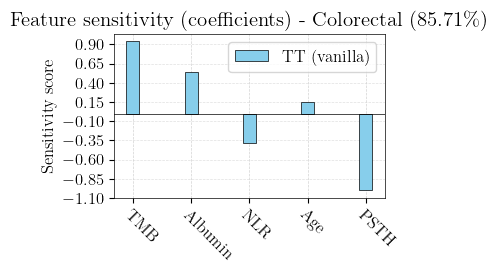

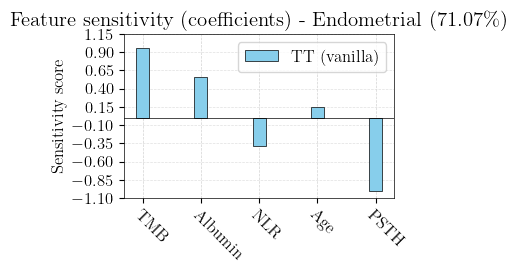

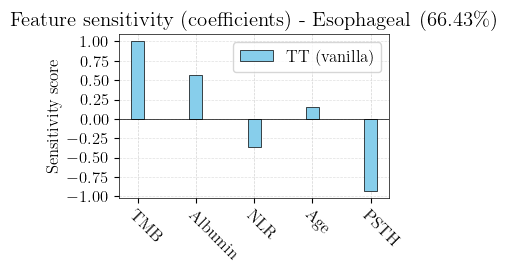

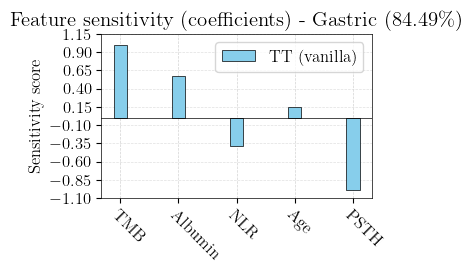

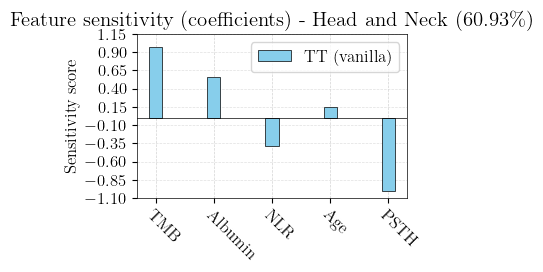

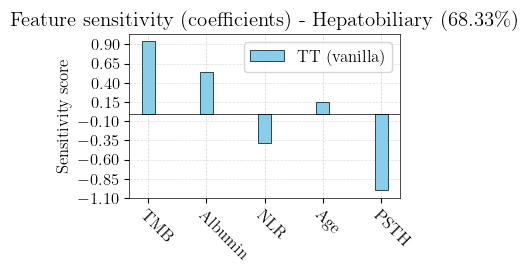

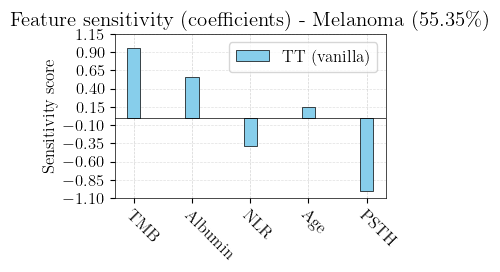

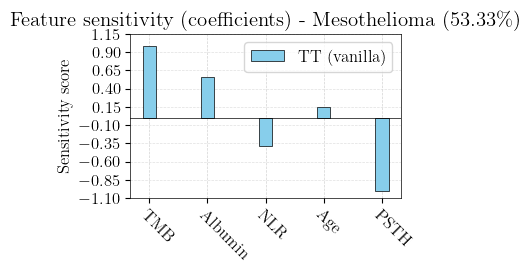

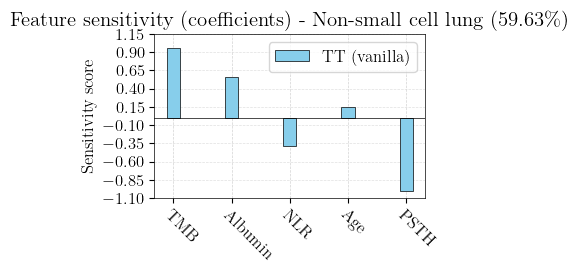

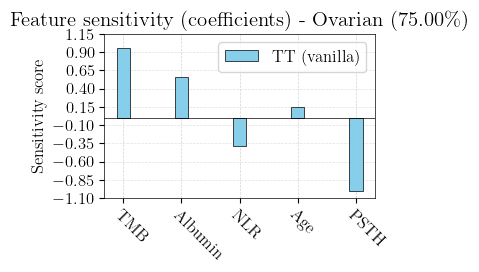

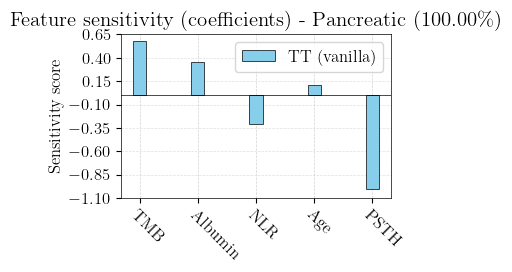

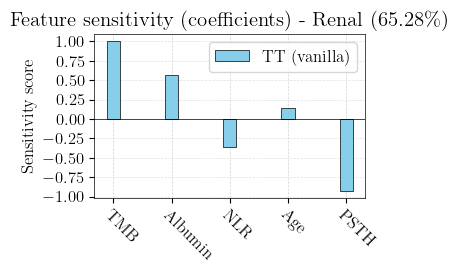

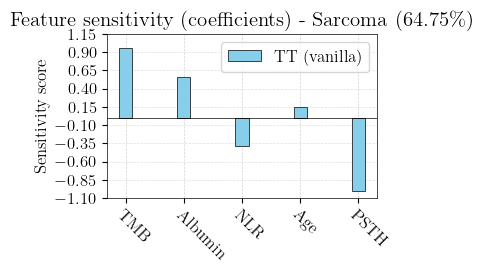

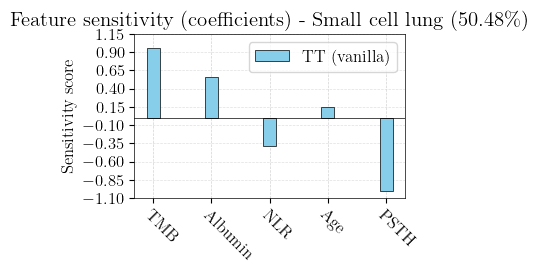

In [45]:
for cancer_idx in range(16):
    # Bar plot setup
    x = torch.arange(len(aux_featuresNA)) * 2  # label locations
    width = 0.45  # width of the bars

    fig, ax = plt.subplots(figsize=(4, 3))
    bars = ax.bar(x, scores_by_cancer[cancer_idx], width, 
                  label='TT (vanilla)', color='skyblue', edgecolor='black', linewidth=0.5)

    # Axes settings
    # ax.set_xlabel('Feature')
    ax.set_ylabel('Sensitivity score')
    ax.set_title(f'Feature sensitivity (coefficients) - '
                 f'{list(plot_labels.values())[cancer_idx + 5]} '
                 f'({train_baccs[cancer_idx] * 100:.2f}\%)')
    ax.set_xticks(x)
    ax.set_xticklabels([plot_labels[feat] for feat in aux_featuresNA],
                    rotation=-45, ha='left', rotation_mode='anchor')
    ax.legend(loc='upper right')

    # Horizontal line at y=0
    ax.axhline(0, color='black', linewidth=0.5)

    # Vertical lines at each x-tick
    for xpos in x:
        ax.axvline(x=xpos, color='lightgrey',
                linestyle='--', linewidth=0.5, alpha=1, zorder=-1)

    # Y-ticks every 0.1
    ymin, ymax = ax.get_ylim()
    yticks = np.arange(round(ymin,1), round(ymax+0.1,1), 0.25)
    ax.set_yticks(yticks)

    # Horizontal grey lines at each y-tick
    for y in yticks:
        ax.axhline(y=y, color='lightgrey',
                linestyle='--', linewidth=0.5, alpha=0.7, zorder=-1)

    plt.tight_layout()
    # plt.savefig(os.path.join(figures_dir, 'feat_sensitivity_coeffs.pdf'),
                # bbox_inches='tight')
    plt.show()

## Monotonic plots

In [14]:
# Load data
# ---------
featuresNA = ['TMB', 'Albumin', 'NLR', 'Age', 'Systemic_therapy_history',
              'CancerType1', 'CancerType2', 'CancerType3', 'CancerType4',
              'CancerType5', 'CancerType6', 'CancerType7', 'CancerType8',
              'CancerType9', 'CancerType10', 'CancerType11', 'CancerType12',
              'CancerType13', 'CancerType14', 'CancerType15', 'CancerType16']
phenoNA = 'Response'

numeric_featuresNA = ['TMB', 'Albumin', 'NLR', 'Age']

datasets = ['Chowell_train', 'Chowell_test', 'MSK1', 'MSK2', 'Shim_NSCLC',
            'Kato_panCancer', 'Vanguri_NSCLC', 'Ravi_NSCLC', 'Pradat_panCancer']

# scaler_type = 'minmax'
scaler_type = 'standard'

dataset = datasets #['Chowell_train'] # 'MSK1', 'MSK2'
data_train, scalers_train = load_data(cwd,
                                      featuresNA,
                                      phenoNA,
                                      dataset,
                                      scaler_type)

x_train = data_train[featuresNA].values
y_train = data_train[phenoNA].values

xt_train = torch.from_numpy(x_train).float()
yt_train = torch.from_numpy(y_train)

0.25, 0.71


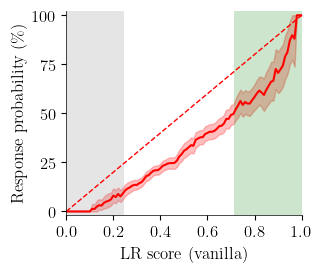

In [18]:
_, x_gray, x_green = response_curve(lr_van_model, xt_train, yt_train,
                                    xlabel='LR score (vanilla)')
print(f'{x_gray:.2f}, {x_green:.2f}')

plt.savefig(os.path.join(figures_dir, 'monotonic_lr_van.pdf'),
            bbox_inches='tight')
plt.show()

0.26, 0.71


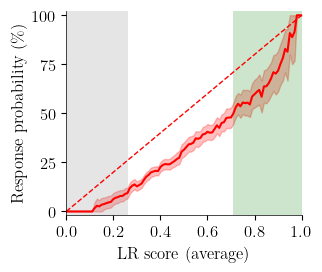

In [54]:
_, x_gray, x_green = response_curve(lr_avg_model, xt_train, yt_train,
                                    xlabel='LR score (average)')
print(f'{x_gray:.2f}, {x_green:.2f}')

plt.savefig(os.path.join(figures_dir, 'monotonic_lr_avg.pdf'),
            bbox_inches='tight')
plt.show()

0.16, 0.80


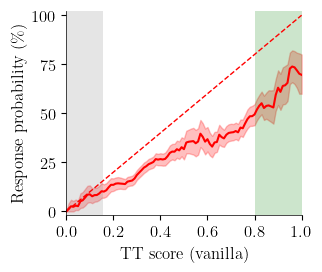

In [57]:
_, x_gray, x_green = response_curve(tt_model, xt_train, yt_train,
                                    xlabel='TT score (vanilla)')
print(f'{x_gray:.2f}, {x_green:.2f}')

plt.savefig(os.path.join(figures_dir, 'monotonic_tt.pdf'),
            bbox_inches='tight')
plt.show()

In [23]:
# Tensorize model
# ---------------
sketch_size    = 50
phys_dim       = 2
domain         = None
bond_dim       = 2
cum_percentage = 1 - 1e-2
batch_size     = 1000
device         = torch.device('cpu')
dtype          = torch.float
verbose        = False


def fn_model(data, n_bins=20):
    # Get probabilities (numpy)
    y_proba = loris_van.predict_proba(data)
    y_proba = torch.from_numpy(y_proba).float()
    
    discr_out = discretize(vector=y_proba, n_bins=n_bins)
    return discr_out.sqrt()

def embedding(data):
    return tk.embeddings.poly(data, degree=phys_dim - 1).float()


mps = tensorize(fn_model=fn_model,
                embedding=embedding,
                x_train=xt_train,
                y_train=yt_train,
                x_test=xt_test,
                y_test=yt_test,
                x_sketch=xt_sketch,
                y_sketch=yt_sketch,
                sketch_size=sketch_size,
                phys_dim=phys_dim,
                domain=domain,
                bond_dim=bond_dim,
                cum_percentage=cum_percentage,
                batch_size=batch_size,
                device=device,
                dtype=dtype,
                verbose=verbose)

*TENSORIZING MODEL*

Info: {'total_time': 0.6147587299346924, 'val_eps': tensor(0.0288)}

MSE: Sketch: 1.22e-03, Train: 0.001, Test: 1.04e-03
tensor([[0.5764, 0.8126],
        [0.7125, 0.6812],
        [0.8326, 0.5502],
        [0.8570, 0.5094],
        [0.8478, 0.5223],
        [0.9529, 0.3936],
        [0.6080, 0.7868],
        [0.8155, 0.5893],
        [0.5669, 0.8108],
        [0.7627, 0.6468]])
tensor([[0.5477, 0.8367],
        [0.7416, 0.6708],
        [0.8367, 0.5477],
        [0.8660, 0.5000],
        [0.8660, 0.5000],
        [0.9220, 0.3873],
        [0.5916, 0.8062],
        [0.8062, 0.5916],
        [0.5477, 0.8367],
        [0.7746, 0.6325]])
tensor([1, 1, 1, 1, 0, 0, 0, 0, 0, 0])

*Sketch accuracies*
Accuracy: TT: 0.65, LR: 0.66
Balanced accuracy: TT: 0.64, LR: 0.65

*Train/test TT accuracies*
Accuracy: Train: 0.68, Test: 0.73
Balanced accuracy: Train: 0.65, Test: 0.70

*Correct predicitons*
Train:
    Class 0: 1452 / 2048 (0.7090)
    Class 1: 486 / 821 (0.5920)
Test:
  

0.22, 0.72


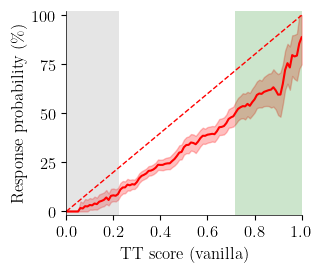

In [24]:
_, x_gray, x_green = response_curve(tt_model, xt_train, yt_train,
                                    xlabel='TT score (vanilla)')
print(f'{x_gray:.2f}, {x_green:.2f}')

plt.savefig(os.path.join(figures_dir, 'monotonic_tt2.pdf'),
            bbox_inches='tight')
plt.show()

In [25]:
@torch.no_grad()
def response_confidence(model, x_train, y_train,
                        bin_size=0.1, bs_number=1000):
    """
    Compute the bootstrapped response probability curve with confidence intervals.

    Parameters
    ----------
    model : torch.nn.Module
        Trained PyTorch model.
    x_train : torch.Tensor
        Input features.
    y_train : torch.Tensor
        True binary outcomes (0/1).
    bin_size : float
        Width of the bin for grouping predictions.
    bs_number : int
        Number of bootstrap resamples.

    Returns
    -------
    score_list : np.ndarray
        The x-axis (prediction score thresholds).
    ORR_mean : np.ndarray
        Mean response probability for each score bin.
    ORR_05 : np.ndarray
        5% quantile (lower bound of CI).
    ORR_95 : np.ndarray
        95% quantile (upper bound of CI).
    """
    import numpy as np
    import random

    # Predictions
    result = model(x_train)
    y_pred = result[:, 1].numpy()
    y_true = y_train.numpy()

    sampleNUM = len(y_true)
    score_list = np.arange(0.0, 1.01, 0.01)
    num_scores = len(score_list)

    # ORR storage
    ORR_list = [[] for _ in range(num_scores)]
    ORR_valid = [False for _ in range(num_scores)]

    # Bootstrapping
    for _ in range(bs_number):
        idx_resampled = random.choices(range(sampleNUM), k=sampleNUM)
        aux_y_true = y_true[idx_resampled]
        aux_y_pred = y_pred[idx_resampled]

        for i, score in enumerate(score_list):
            bin_mask = (aux_y_pred > score - bin_size / 2) & \
                       (aux_y_pred <= score + bin_size / 2)

            if bin_mask.sum() > 0:
                ORR_list[i].append(aux_y_true[bin_mask].mean())
                ORR_valid[i] = True
            else:
                ORR_list[i].append(np.nan)

    # Compute statistics, skipping NaNs
    ORR_mean = np.array([np.nanmean(x) if ORR_valid[i] else np.nan
                         for i, x in enumerate(ORR_list)])
    ORR_05 = np.array([np.nanquantile(x, 0.05) if ORR_valid[i] else np.nan
                       for i, x in enumerate(ORR_list)])
    ORR_95 = np.array([np.nanquantile(x, 0.95) if ORR_valid[i] else np.nan
                       for i, x in enumerate(ORR_list)])

    # Forward-fill missing values
    def forward_fill(arr):
        filled = []
        last_val = np.nan
        for val in arr:
            if not np.isnan(val):
                last_val = val
            filled.append(last_val)
        return np.array(filled)

    ORR_mean = forward_fill(ORR_mean)
    ORR_05 = forward_fill(ORR_05)
    ORR_95 = forward_fill(ORR_95)

    return score_list, ORR_mean, ORR_05, ORR_95


In [27]:
response_confidence(tt_model, xt_train, yt_train)

(array([0.  , 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1 ,
        0.11, 0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19, 0.2 , 0.21,
        0.22, 0.23, 0.24, 0.25, 0.26, 0.27, 0.28, 0.29, 0.3 , 0.31, 0.32,
        0.33, 0.34, 0.35, 0.36, 0.37, 0.38, 0.39, 0.4 , 0.41, 0.42, 0.43,
        0.44, 0.45, 0.46, 0.47, 0.48, 0.49, 0.5 , 0.51, 0.52, 0.53, 0.54,
        0.55, 0.56, 0.57, 0.58, 0.59, 0.6 , 0.61, 0.62, 0.63, 0.64, 0.65,
        0.66, 0.67, 0.68, 0.69, 0.7 , 0.71, 0.72, 0.73, 0.74, 0.75, 0.76,
        0.77, 0.78, 0.79, 0.8 , 0.81, 0.82, 0.83, 0.84, 0.85, 0.86, 0.87,
        0.88, 0.89, 0.9 , 0.91, 0.92, 0.93, 0.94, 0.95, 0.96, 0.97, 0.98,
        0.99, 1.  ]),
 array([0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.01800395, 0.01570157, 0.0271406 , 0.0257047 ,
        0.03302968, 0.03133041, 0.04016215, 0.03713071, 0.05046136,
        0.05444674, 0.06015544, 0.07330365, 0.06025497, 0.08165802,
        0.0839963 , 0.08155208, 0.090716

In [ ]:
@torch.no_grad()
def response_confidence_at_score(model, x_train, y_train, score,
                                 bin_size=0.1, bs_number=1000):
    """
    Compute the bootstrapped confidence interval of the response probability
    at a given prediction score.

    Parameters
    ----------
    model : torch.nn.Module
        Trained PyTorch model.
    x_train : torch.Tensor
        Input features.
    y_train : torch.Tensor
        True binary outcomes (0/1).
    score : float
        Prediction score of interest (between 0 and 1).
    bin_size : float
        Width of the bin for grouping predictions around the score.
    bs_number : int
        Number of bootstrap resamples.

    Returns
    -------
    mean_val : float
        Mean response probability at the given score.
    low_val : float
        Lower bound of the 95% confidence interval (5% quantile).
    high_val : float
        Upper bound of the 95% confidence interval (95% quantile).
    """
    import numpy as np
    import random

    # Predictions
    result = model(x_train)
    y_pred = result[:, 1].numpy()
    y_true = y_train.numpy()

    sampleNUM = len(y_true)
    ORR_values = []

    # Bootstrapping
    for _ in range(bs_number):
        idx_resampled = random.choices(range(sampleNUM), k=sampleNUM)
        aux_y_true = y_true[idx_resampled]
        aux_y_pred = y_pred[idx_resampled]

        # Bin mask around the given score
        bin_mask = (aux_y_pred > score - bin_size / 2) & \
                   (aux_y_pred <= score + bin_size / 2)

        if bin_mask.sum() > 0:
            ORR_values.append(aux_y_true[bin_mask].mean())
        else:
            ORR_values.append(np.nan)

    # Convert to array
    ORR_values = np.array(ORR_values)

    # Drop NaNs if they exist
    ORR_values = ORR_values[~np.isnan(ORR_values)]
    if len(ORR_values) == 0:
        return np.nan, np.nan, np.nan

    # Mean and CI
    mean_val = float(np.mean(ORR_values))
    low_val = float(np.quantile(ORR_values, 0.05))
    high_val = float(np.quantile(ORR_values, 0.95))

    return mean_val, low_val, high_val


In [34]:
@torch.no_grad()
def response_confidence_inverse(model, x_train, y_train, mean_value,
                                bin_size=0.1, bs_number=1000):
    """
    Given a target mean response probability, return the corresponding score
    (decision threshold) using the bootstrapped response curve.

    Parameters
    ----------
    model : torch.nn.Module
        Trained PyTorch model.
    x_train : torch.Tensor
        Input features.
    y_train : torch.Tensor
        True binary outcomes (0/1).
    mean_value : float
        Desired mean response probability (between 0 and 1).
    bin_size : float
        Width of the bin for grouping predictions.
    bs_number : int
        Number of bootstrap resamples.

    Returns
    -------
    score : float
        The score (threshold) corresponding to the given mean response.
    """

    import numpy as np
    from scipy.interpolate import interp1d

    # Get the response curve
    score_list, ORR_mean, ORR_05, ORR_95 = response_confidence(
        model, x_train, y_train, bin_size=bin_size, bs_number=bs_number
    )

    # Remove NaNs for interpolation
    valid_mask = ~np.isnan(ORR_mean)
    valid_scores = score_list[valid_mask]
    valid_means = ORR_mean[valid_mask]

    if len(valid_scores) == 0:
        raise ValueError("No valid bins found for interpolation.")

    # Build inverse interpolation function: mean -> score
    inv_func = interp1d(valid_means, valid_scores,
                        bounds_error=False,
                        fill_value=(valid_scores[0], valid_scores[-1]))

    # Get the score for the desired mean
    score = float(inv_func(mean_value))
    return score


In [35]:
response_confidence_inverse(lr_van_model, xt_train, yt_train, 0.17)

0.33381876380808023

In [37]:
response_confidence_inverse(lr_van_model, xt_train, yt_train, 0.21)

0.3835019394244152